# 07 — Chronos Fine-Tuned with LoRA (PV Dataset)

**Base model:** `amazon/chronos-t5-small`  
**Fine-tuning:** LoRA (Low-Rank Adaptation) on LARES PV training split (2018-04 → 2019-12)  
**Comparison:** Same test windows as zero-shot Chronos (`03_chronos.ipynb`)

**Why LoRA?**
- Trains only ~1% of parameters → fast on CPU/MPS, minimal memory
- Avoids catastrophic forgetting of pre-trained knowledge
- Applied to T5 attention matrices (q, v projections)
- Industry-standard approach (used by AutoGluon/AWS for Chronos fine-tuning)

**Prerequisite:**
```bash
pip install chronos-forecasting peft
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import time
import os
from tqdm import tqdm

import torch
from chronos import ChronosPipeline
from peft import get_peft_model, LoraConfig, TaskType

os.makedirs('../results', exist_ok=True)
os.makedirs('../figure',  exist_ok=True)
os.makedirs('../models',  exist_ok=True)

# ── Device ──
if torch.backends.mps.is_available():
    device = 'mps'
elif torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'
print(f'Device: {device}')

# ── Config ──
CONTEXT_LENGTH    = 512
PREDICTION_LENGTH = 96
STRIDE_TEST       = 96
STRIDE_TRAIN      = 96
NUM_SAMPLES       = 20
EPOCHS            = 5
LR                = 1e-4
BATCH_SIZE        = 8
LORA_R            = 8      # LoRA rank
LORA_ALPHA        = 32     # LoRA scaling
LORA_DROPOUT      = 0.1
MAX_WINDOWS       = None   # set e.g. 10 for a quick smoke-test
MODEL_NAME        = 'Chronos (fine-tuned)'
BASE_MODEL_ID     = 'amazon/chronos-t5-small'
SAVE_PATH         = '../models/chronos_lora_adapter'

Device: mps


## 1. Load & Prepare Data

In [2]:
df = pd.read_csv('../data/dataset.csv', index_col='timestamp', parse_dates=True)
df.index = df.index.tz_localize('UTC').tz_convert('Europe/Zagreb').tz_localize(None)

agg = {
    'power'             : 'sum',
    'sun_zenith'        : 'mean',
    'sun_azimuth'       : 'mean',
    'temperature'       : 'mean',
    'global_irradiance' : 'mean',
    'direct_irradiance' : 'mean',
    'diffuse_irradiance': 'mean',
}
df_full = df.resample('15min', closed='left', label='left').agg(agg)
df_full['power'] = df_full['power'].fillna(0).clip(lower=0)
wx_cols = [c for c in df_full.columns if c != 'power']
df_full[wx_cols] = df_full[wx_cols].ffill().fillna(0)
df_full['solar_elevation'] = (90 - df_full['sun_zenith']).clip(lower=0)

full_series = df_full['power'].values.astype(np.float32)

train_mask = df_full.index < pd.Timestamp('2020-01-01')
test_mask  = (df_full.index >= pd.Timestamp('2020-01-01')) & \
             (df_full.index <= pd.Timestamp('2020-08-01'))

train_indices   = np.where(train_mask)[0]
test_indices    = np.where(test_mask)[0]
train_start_idx = int(train_indices[0])
train_end_idx   = int(train_indices[-1])
test_start_idx  = int(test_indices[0])
test_end_idx    = int(test_indices[-1])

print(f'15-min grid : {df_full.shape}')
print(f'Train       : {df_full.index[train_start_idx].date()} → {df_full.index[train_end_idx].date()} ({len(train_indices):,} steps)')
print(f'Test        : {df_full.index[test_start_idx].date()} → {df_full.index[test_end_idx].date()} ({len(test_indices):,} steps)')

15-min grid : (171139, 8)
Train       : 2018-04-17 → 2019-12-31 (59,875 steps)
Test        : 2020-01-01 → 2020-08-01 (20,449 steps)


## 2. Load Pretrained Chronos & Apply LoRA

`ChronosPipeline.model` is a `ChronosModel` wrapper.  
The underlying `T5ForConditionalGeneration` lives at `pipeline.model.model` —  
that is what we fine-tune so we can use the standard HuggingFace `labels=` / `.loss` API.

In [3]:
print(f'Loading {BASE_MODEL_ID} ...')
t0 = time.time()

pipeline = ChronosPipeline.from_pretrained(
    BASE_MODEL_ID,
    device_map=device,
    torch_dtype=torch.float32,
)

tok = pipeline.tokenizer
print(f'Loaded in {time.time()-t0:.1f}s')
print(f'ChronosModel wrapper : {type(pipeline.model).__name__}')
print(f'Inner T5 model       : {type(pipeline.model.model).__name__}')
print(f'Total params         : {sum(p.numel() for p in pipeline.model.parameters()):,}')

Loading amazon/chronos-t5-small ...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loaded in 4.4s
ChronosModel wrapper : ChronosModel
Inner T5 model       : T5ForConditionalGeneration
Total params         : 46,154,240


In [4]:
# ── Apply LoRA to the inner T5ForConditionalGeneration ──
lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=['q', 'v'],   # T5 attention query & value projections
    lora_dropout=LORA_DROPOUT,
    bias='none',
)

# Wrap the inner T5 model with LoRA (modifies it in-place in the pipeline)
t5_model = get_peft_model(pipeline.model.model, lora_cfg)
t5_model.print_trainable_parameters()

# Point pipeline.model.model to the LoRA-wrapped version
# (pipeline.predict() will automatically use the fine-tuned weights)
pipeline.model.model = t5_model

trainable params: 294,912 || all params: 46,449,152 || trainable%: 0.6349


In [5]:
# ── Tokenizer helpers ──
# context_input_transform works fine; we tokenize labels manually
# using the tokenizer's bin boundaries to avoid version-specific API issues.
_boundaries = tok.boundaries
if not isinstance(_boundaries, torch.Tensor):
    _boundaries = torch.tensor(_boundaries, dtype=torch.float32)
_boundaries = _boundaries.cpu()

def tokenize_ctx(ctx_batch):
    """(input_ids, attention_mask, scale) — all on CPU."""
    return tok.context_input_transform(ctx_batch)

def tokenize_lbl(tgt_batch, scale):
    """label_ids on CPU via direct bucketize on tokenizer boundaries."""
    scale_2d = scale.view(-1, 1) if scale.dim() == 1 else scale  # ensure (B, 1)
    lbl_norm  = tgt_batch / scale_2d
    return torch.bucketize(lbl_norm.cpu(), _boundaries)

# ── Sanity check: one forward pass before training ──
t5_model.train()
t5_model.to(device)

_ctx = torch.tensor(full_series[:CONTEXT_LENGTH],                              dtype=torch.float32).unsqueeze(0)
_tgt = torch.tensor(full_series[CONTEXT_LENGTH:CONTEXT_LENGTH+PREDICTION_LENGTH], dtype=torch.float32).unsqueeze(0)
_ids, _mask, _scale = tokenize_ctx(_ctx)
_lbl = tokenize_lbl(_tgt, _scale)

with torch.no_grad():
    _out  = t5_model(input_ids=_ids.to(device), attention_mask=_mask.to(device), labels=_lbl.to(device))
    _loss = _out.loss

print(f'input_ids shape : {_ids.shape}  (dtype={_ids.dtype})')
print(f'label_ids shape : {_lbl.shape}  (dtype={_lbl.dtype})')
print(f'\n✓ Sanity check passed. Initial loss = {_loss.item():.4f}')
del _ctx, _tgt, _ids, _mask, _scale, _lbl, _out, _loss

input_ids shape : torch.Size([1, 513])  (dtype=torch.int64)
label_ids shape : torch.Size([1, 96])  (dtype=torch.int64)

✓ Sanity check passed. Initial loss = 3.6200


## 3. Build Training Windows

In [6]:
train_window_starts = list(range(
    train_start_idx + CONTEXT_LENGTH,
    train_end_idx - PREDICTION_LENGTH + 1,
    STRIDE_TRAIN,
))
print(f'Training windows  : {len(train_window_starts)}')
print(f'Batches per epoch : {len(train_window_starts) // BATCH_SIZE}')

Training windows  : 618
Batches per epoch : 77


## 4. Fine-Tune with LoRA

In [7]:
t5_model.train()
t5_model.to(device)

optimizer = torch.optim.Adam(t5_model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS * (len(train_window_starts) // BATCH_SIZE + 1)
)

epoch_losses = []
print(f'Fine-tuning {BASE_MODEL_ID} (LoRA r={LORA_R}) for {EPOCHS} epochs ...')
ft_start = time.time()

for epoch in range(EPOCHS):
    rng      = np.random.default_rng(epoch)
    shuffled = rng.permutation(train_window_starts).tolist()
    batch_losses = []

    pbar = tqdm(range(0, len(shuffled), BATCH_SIZE),
                desc=f'Epoch {epoch+1}/{EPOCHS}', leave=True)

    for b_start in pbar:
        batch_idx = shuffled[b_start : b_start + BATCH_SIZE]

        ctx_list, tgt_list = [], []
        for i in batch_idx:
            ctx_list.append(torch.tensor(full_series[i - CONTEXT_LENGTH : i],    dtype=torch.float32))
            tgt_list.append(torch.tensor(full_series[i : i + PREDICTION_LENGTH], dtype=torch.float32))

        ctx_batch = torch.stack(ctx_list)   # (B, context_len)
        tgt_batch = torch.stack(tgt_list)   # (B, pred_len)

        # ── Tokenize ──
        input_ids, attention_mask, scale = tokenize_ctx(ctx_batch)
        label_ids = tokenize_lbl(tgt_batch, scale)

        input_ids      = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        label_ids      = label_ids.to(device)

        optimizer.zero_grad()

        # ── Forward pass (standard HuggingFace T5 API) ──
        out  = t5_model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=label_ids)
        loss = out.loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(t5_model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        batch_losses.append(loss.item())
        pbar.set_postfix({'loss': f'{np.mean(batch_losses):.4f}'})

    epoch_loss = np.mean(batch_losses)
    epoch_losses.append(epoch_loss)
    print(f'  Epoch {epoch+1} mean loss: {epoch_loss:.4f}')

ft_time = time.time() - ft_start
print(f'\nFine-tuning complete in {ft_time/60:.1f} min')

# Save LoRA adapter weights (small — only the trained delta weights)
t5_model.save_pretrained(SAVE_PATH)
print(f'Saved LoRA adapter → {SAVE_PATH}/')

Fine-tuning amazon/chronos-t5-small (LoRA r=8) for 5 epochs ...


Epoch 1/5: 100%|███████████████████| 78/78 [00:45<00:00,  1.72it/s, loss=2.6424]


  Epoch 1 mean loss: 2.6424


Epoch 2/5: 100%|███████████████████| 78/78 [00:42<00:00,  1.85it/s, loss=2.0656]


  Epoch 2 mean loss: 2.0656


...

  Epoch 3 mean loss: 2.0275


Epoch 4/5: 100%|███████████████████| 78/78 [00:47<00:00,  1.66it/s, loss=2.0050]


  Epoch 4 mean loss: 2.0050


Epoch 5/5: 100%|███████████████████| 78/78 [00:52<00:00,  1.47it/s, loss=1.9840]


  Epoch 5 mean loss: 1.9840

Fine-tuning complete in 3.8 min
Saved LoRA adapter → ../models/chronos_lora_adapter/


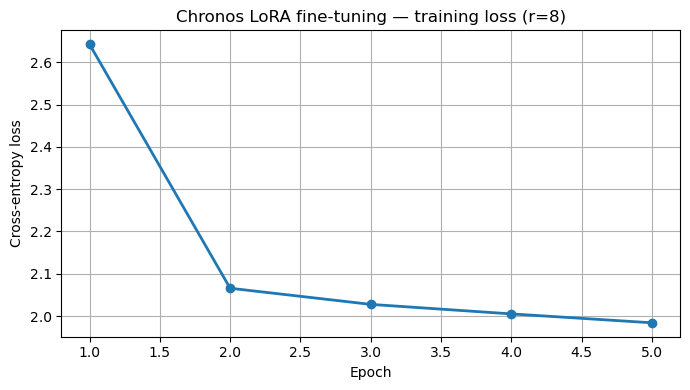

Saved → ../figure/07_chronos_ft_loss.png


In [8]:
# ── Training loss curve ──
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS+1), epoch_losses, marker='o', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Cross-entropy loss')
plt.title(f'Chronos LoRA fine-tuning — training loss (r={LORA_R})')
plt.grid(True); plt.tight_layout()
plt.savefig('../figure/07_chronos_ft_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../figure/07_chronos_ft_loss.png')

## 5. Rolling 24h-Ahead Evaluation

`pipeline.predict()` uses `pipeline.model.model` internally,  
which is now the LoRA-fine-tuned T5 → no extra setup needed.

In [9]:
t5_model.eval()

def predict_chronos_ft(context_array):
    ctx = torch.tensor(context_array, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        forecast = pipeline.predict(
            ctx,
            prediction_length=PREDICTION_LENGTH,
            num_samples=NUM_SAMPLES,
        )
    return np.clip(np.quantile(forecast[0].numpy(), 0.5, axis=0), 0, None)


start_positions = list(range(test_start_idx, test_end_idx - PREDICTION_LENGTH + 1, STRIDE_TEST))
if MAX_WINDOWS:
    start_positions = start_positions[:MAX_WINDOWS]

n           = len(start_positions)
all_preds   = np.zeros((n, PREDICTION_LENGTH), dtype=np.float32)
all_actuals = np.zeros((n, PREDICTION_LENGTH), dtype=np.float32)
all_ts      = []
infer_times = []

for w, i in enumerate(tqdm(start_positions, desc='Chronos FT rolling eval')):
    ctx_start = max(0, i - CONTEXT_LENGTH)
    context   = full_series[ctx_start:i]
    actual    = full_series[i:i + PREDICTION_LENGTH]
    ts        = df_full.index[i:i + PREDICTION_LENGTH]

    t0 = time.time()
    pred = predict_chronos_ft(context)
    infer_times.append(time.time() - t0)

    all_preds[w]   = pred[:PREDICTION_LENGTH]
    all_actuals[w] = actual
    all_ts.append(ts)

print(f'Done. Avg inference time: {np.mean(infer_times):.3f}s per 24h window')

We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

Done. Avg inference time: 1.701s per 24h window


## 6. Metrics — Daytime & All-Hours

In [10]:
preds_flat   = np.clip(all_preds.ravel(), 0, None)
actuals_flat = all_actuals.ravel()
ts_flat      = pd.DatetimeIndex(np.concatenate([t.values for t in all_ts]))

solar_elev = df_full['solar_elevation'].reindex(ts_flat).values
day_mask   = solar_elev > 5

def metrics(y_true, y_pred, label):
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    nrmse = rmse / y_true.max()
    print(f'[{label}]  MAE={mae:.4f}  RMSE={rmse:.4f}  nRMSE={nrmse:.4f}')
    return mae, rmse, nrmse

print(f'=== {MODEL_NAME} ===')
mae_d, rmse_d, nrmse_d = metrics(actuals_flat[day_mask], preds_flat[day_mask], 'Daytime (solar_elev > 5°)')
mae_a, rmse_a, nrmse_a = metrics(actuals_flat,           preds_flat,           'All-hours')

avg_infer = np.mean(infer_times)
print(f'\nFine-tune time      : {ft_time:.1f}s  ({ft_time/60:.1f} min)')
print(f'Avg inference / 24h : {avg_infer:.3f}s')
print(f'Daytime samples     : {day_mask.sum()} / {len(day_mask)}')

=== Chronos (fine-tuned) ===
[Daytime (solar_elev > 5°)]  MAE=0.1629  RMSE=0.2237  nRMSE=0.2602
[All-hours]  MAE=0.1022  RMSE=0.1791  nRMSE=0.2083

Fine-tune time      : 230.6s  (3.8 min)
Avg inference / 24h : 1.701s
Daytime samples     : 9930 / 20448


## 7. Plots

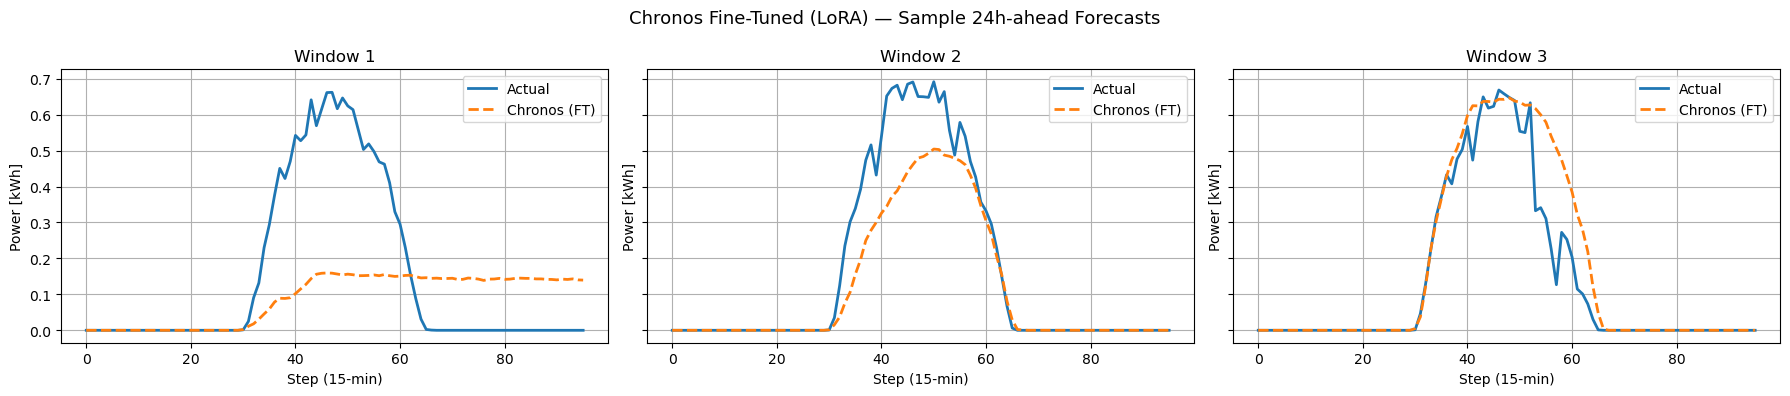

Saved → ../figure/07_chronos_ft_sample_forecasts.png


In [11]:
# ── Sample forecasts ──
sunny_windows = [w for w in range(n) if all_actuals[w].max() > 0.01][:3]

fig, axes = plt.subplots(1, len(sunny_windows), figsize=(6 * len(sunny_windows), 4), sharey=True)
if len(sunny_windows) == 1:
    axes = [axes]

for ax, w in zip(axes, sunny_windows):
    ax.plot(all_actuals[w], label='Actual',       linewidth=2)
    ax.plot(all_preds[w],   label='Chronos (FT)', linewidth=2, linestyle='--')
    ax.set_title(f'Window {w+1}')
    ax.set_xlabel('Step (15-min)'); ax.set_ylabel('Power [kWh]')
    ax.legend(); ax.grid(True)

plt.suptitle('Chronos Fine-Tuned (LoRA) — Sample 24h-ahead Forecasts', fontsize=13)
plt.tight_layout()
plt.savefig('../figure/07_chronos_ft_sample_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../figure/07_chronos_ft_sample_forecasts.png')

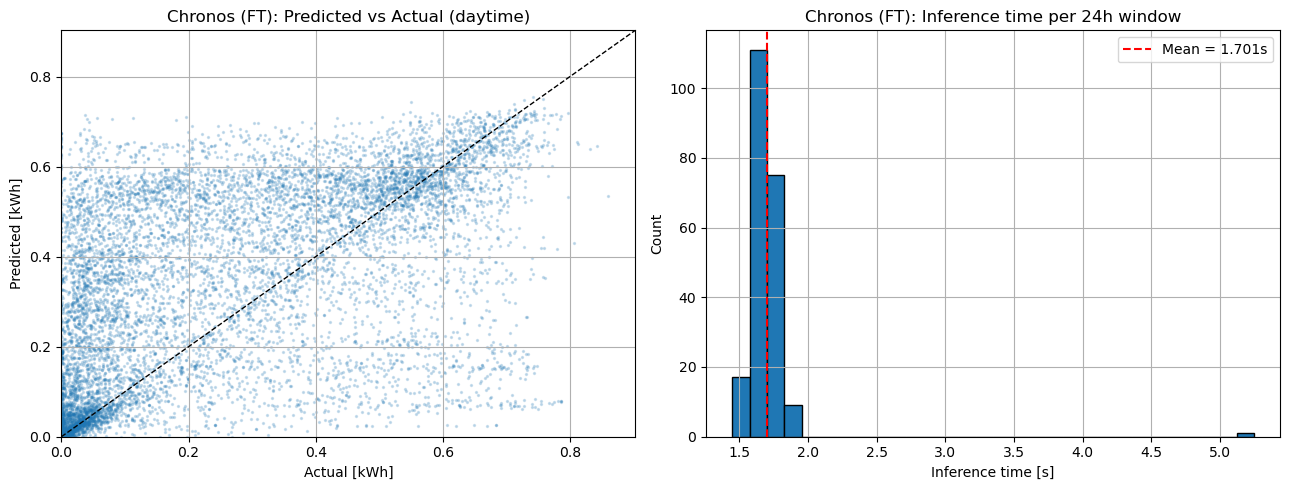

Saved → ../figure/07_chronos_ft_eval.png


In [12]:
# ── Scatter + inference time ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lim = max(actuals_flat[day_mask].max(), preds_flat[day_mask].max()) * 1.05
axes[0].scatter(actuals_flat[day_mask], preds_flat[day_mask], s=2, alpha=0.2)
axes[0].plot([0, lim], [0, lim], 'k--', linewidth=1)
axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
axes[0].set_xlabel('Actual [kWh]'); axes[0].set_ylabel('Predicted [kWh]')
axes[0].set_title('Chronos (FT): Predicted vs Actual (daytime)')
axes[0].grid(True)

axes[1].hist(infer_times, bins=30, edgecolor='black')
axes[1].axvline(avg_infer, color='red', linestyle='--', label=f'Mean = {avg_infer:.3f}s')
axes[1].set_xlabel('Inference time [s]'); axes[1].set_ylabel('Count')
axes[1].set_title('Chronos (FT): Inference time per 24h window')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('../figure/07_chronos_ft_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../figure/07_chronos_ft_eval.png')

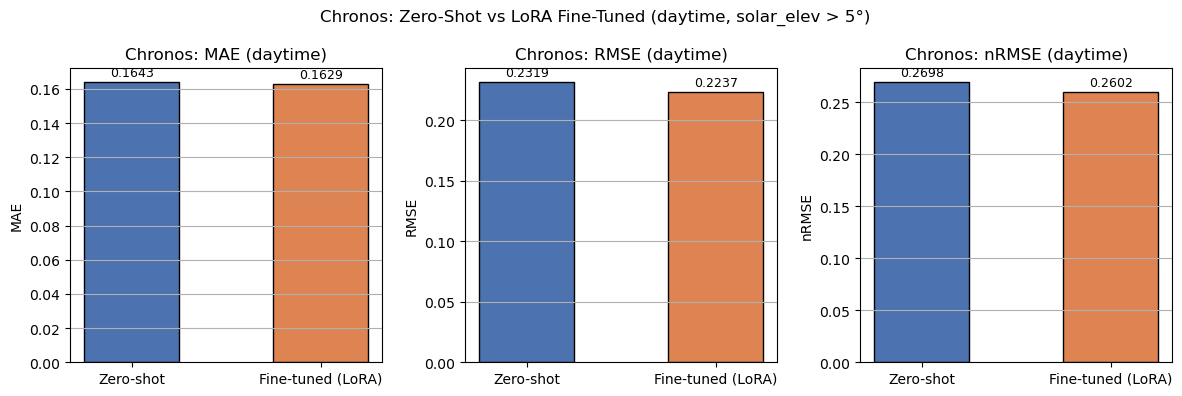

Saved → ../figure/07_chronos_zs_vs_ft.png


In [13]:
# ── Zero-shot vs Fine-tuned comparison ──
comp_path = '../results/comparison.csv'
existing  = pd.read_csv(comp_path) if os.path.exists(comp_path) else pd.DataFrame()
zs_rows   = existing[existing['Model'] == 'Chronos'] if len(existing) else pd.DataFrame()

if len(zs_rows):
    labels     = ['Zero-shot', 'Fine-tuned (LoRA)']
    mae_vals   = [float(zs_rows['MAE'].values[0]),   mae_d]
    rmse_vals  = [float(zs_rows['RMSE'].values[0]),  rmse_d]
    nrmse_vals = [float(zs_rows['nRMSE'].values[0]), nrmse_d]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    colors = ['#4C72B0', '#DD8452']
    for ax, vals, title in zip(axes,
                               [mae_vals, rmse_vals, nrmse_vals],
                               ['MAE', 'RMSE', 'nRMSE']):
        bars = ax.bar(labels, vals, color=colors, edgecolor='black', width=0.5)
        ax.set_title(f'Chronos: {title} (daytime)')
        ax.set_ylabel(title); ax.grid(axis='y')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() * 1.01,
                    f'{v:.4f}', ha='center', va='bottom', fontsize=9)

    plt.suptitle('Chronos: Zero-Shot vs LoRA Fine-Tuned (daytime, solar_elev > 5°)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../figure/07_chronos_zs_vs_ft.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → ../figure/07_chronos_zs_vs_ft.png')
else:
    print('Zero-shot Chronos row not found in comparison.csv — run 03_chronos.ipynb first.')

## 8. Save Results

In [14]:
pd.DataFrame({
    'timestamp'        : ts_flat,
    'actual'           : actuals_flat,
    'chronos_finetuned': preds_flat,
    'solar_elev'       : solar_elev,
    'daytime'          : day_mask,
}).to_pickle('../results/chronos_finetuned_predictions.pkl')
print('Saved → ../results/chronos_finetuned_predictions.pkl')

Saved → ../results/chronos_finetuned_predictions.pkl


In [15]:
comp_cols = ['Model', 'MAE', 'RMSE', 'nRMSE', 'Train Time', 'Inference Time']

new_rows = pd.DataFrame([
    {'Model': MODEL_NAME,                'MAE': mae_d, 'RMSE': rmse_d, 'nRMSE': nrmse_d,
     'Train Time': ft_time, 'Inference Time': avg_infer},
    {'Model': f'{MODEL_NAME} (all-hrs)', 'MAE': mae_a, 'RMSE': rmse_a, 'nRMSE': nrmse_a,
     'Train Time': ft_time, 'Inference Time': avg_infer},
])

if os.path.exists(comp_path):
    existing = pd.read_csv(comp_path)
    existing = existing[~existing['Model'].isin(new_rows['Model'])]
    combined = pd.concat([existing, new_rows], ignore_index=True)
else:
    combined = new_rows

combined[comp_cols].to_csv(comp_path, index=False)
print(f'Saved → {comp_path}')
print()
print(combined[comp_cols].to_string(index=False))

Saved → ../results/comparison.csv

                         Model      MAE     RMSE    nRMSE  Train Time  Inference Time
                      LightGBM 0.021175 0.034823 0.040512    0.196141        0.014383
              LightGBM (tuned) 0.020895 0.034539 0.040182   66.418172        0.037487
                           MLP 0.020945 0.034464 0.040095    2.954158        0.017441
                       Chronos 0.164308 0.231903 0.269790    0.000000        1.622153
             Chronos (all-hrs) 0.104663 0.188088 0.218817    0.000000        1.622153
                       TimesFM 0.124079 0.178613 0.207794    0.000000        0.077968
             TimesFM (all-hrs) 0.062519 0.126753 0.147461    0.000000        0.077968
                        Moirai 0.222258 0.326228 0.379526    0.000000        0.017504
              Moirai (all-hrs) 0.247542 0.430665 0.501025    0.000000        0.017504
                        TabPFN 0.045660 0.089320 0.103913   11.576127        2.581436
              TabPF